In [37]:
from huggingface_hub import login
login()

In [38]:
# Used to securely store your API key
from google.colab import userdata
import os

# Get Hugging Face token from Colab secrets
HF_TOKEN = userdata.get('HF_TOKEN')

# Log in to Hugging Face Hub
from huggingface_hub import login
login(token=HF_TOKEN)

In [2]:
# ── CELL 1: Install ──────────────────────────────────────────────────────────
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git" -q
!pip install trl datasets transformers requests matplotlib -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 11.2 MB/s et

In [3]:
# ── CELL 2: Config — fill in your Space URL ──────────────────────────────────
ENV_BASE_URL = "https://dhanwalkarjay-openenv-code-review.hf.space"
MODEL_NAME   = "Qwen/Qwen2.5-0.5B-Instruct"
MAX_STEPS    = 80
OUTPUT_DIR   = "grpo_output"
TASK_TYPES   = ["easy", "medium", "hard"]

In [4]:
# ── CELL 3: Sanity check your Space endpoints FIRST ──────────────────────────
import requests

def env_reset(task_type: str) -> dict:
    r = requests.post(f"{ENV_BASE_URL}/reset",
                      json={"task_type": task_type}, timeout=30)
    r.raise_for_status()
    return r.json()

def env_step(fixed_code: str, task_type: str) -> dict:
    r = requests.post(f"{ENV_BASE_URL}/step",
                      json={"fixed_code": fixed_code, "task_type": task_type},
                      timeout=30)
    r.raise_for_status()
    return r.json()

# Run this before anything else — if it fails, fix the Space first
print("Testing /reset...")
obs = env_reset("easy")
print("✅ reset OK:", obs)

print("Testing /step...")
result = env_step("def safe_div(a,b):\n    if b==0: return 0\n    return a/b", "easy")
print("✅ step OK:", result)

Testing /reset...
✅ reset OK: {'task_id': 'arena-001', 'title': 'Fix index error', 'instruction': 'Fix the index error so the function returns the third item safely.', 'buggy_code': 'def get_third_item(items):\n    return items[3]\n', 'current_code': 'def get_third_item(items):\n    return items[3]\n', 'previous_step_output': None, 'step_count': 0, 'max_steps': 3, 'tests_passed': 0, 'tests_total': 3, 'total_reward': 0.0, 'history': [], 'done': False}
Testing /step...
✅ step OK: {'observation': {'task_id': 'arena-001', 'title': 'Fix index error', 'instruction': 'Fix the index error so the function returns the third item safely.', 'buggy_code': 'def get_third_item(items):\n    return items[3]\n', 'current_code': 'def safe_div(a,b):\n    if b==0: return 0\n    return a/b', 'previous_step_output': {'step': 1, 'reviewer_output': ['No obvious syntax errors; run tests to verify behavior.'], 'fixer_output': 'def safe_div(a,b):\n    if b==0: return 0\n    return a/b', 'reward': 0.5, 'reward_com

In [18]:
for t in ["easy", "medium", "hard", "bonus", "max_init", "none_lower"]:
    obs = env_reset(t)
    print(f"{t}: {obs['task_id']} — {obs['title']}")

easy: arena-001 — Fix index error
medium: arena-002 — Fix syntax error
hard: arena-003 — Fix division by zero
bonus: arena-004 — Fix off-by-one loop
max_init: arena-007 — Fix max initialization
none_lower: arena-006 — Handle None before lower


In [5]:
# ── CELL 4: Build dataset ────────────────────────────────────────────────────
from datasets import Dataset

SYSTEM_PROMPT = (
    "You are an expert Python debugger. "
    "Given a buggy Python function, return ONLY the corrected Python code. "
    "No explanation. No markdown fences. Just valid Python."
)

rows = []
for task_type in TASK_TYPES:
    obs = env_reset(task_type)
    buggy       = obs.get("current_code", obs.get("buggy_code", "# unknown"))
    instruction = obs.get("instruction", "Fix the bug.")
    rows.append({
        "task_type": task_type,
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": f"Instruction: {instruction}\n\nBuggy code:\n{buggy}"},
        ],
    })

rows = rows * 30  # 90 rows — enough for 80 GRPO steps
dataset = Dataset.from_list(rows)
print(f"✅ Dataset ready: {len(dataset)} rows")

✅ Dataset ready: 90 rows


#### Re-installing `unsloth`

Since the Colab runtime often restarts after changing the hardware accelerator, previously installed packages like `unsloth` need to be re-installed. The following cell will re-install `unsloth` and its dependencies.

In [2]:
# Re-install unsloth and its dependencies after runtime restart
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git" -q
!pip install trl datasets transformers requests matplotlib -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 124.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 421.9/421.9 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 118.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 108.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.0/225.0 kB 22.7 MB/s eta 0:00:00


In [4]:
# Define MODEL_NAME as it was not found in the current environment.
# Note: This variable is also defined in cell `6eiusYJWmZpx` which should be run for full environment setup.
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"

In [5]:
# ── CELL 5: Load model ───────────────────────────────────────────────────────
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = MODEL_NAME,
    max_seq_length = 512,
    dtype          = None,
    load_in_4bit   = True,
)
model = FastLanguageModel.get_peft_model(
    model,
    r                          = 16,
    target_modules             = ["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_alpha                 = 16,
    lora_dropout               = 0,
    bias                       = "none",
    use_gradient_checkpointing = "unsloth",
    random_state               = 42,
)
print("✅ Model loaded")

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/538M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/qwen2.5-0.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.4.8 patched 24 layers with 24 QKV layers, 24 O layers and 0 MLP layers.


✅ Model loaded


In [6]:
# ── CELL 6: Reward functions ─────────────────────────────────────────────────
import ast

def reward_tests_pass(completions, task_type, **kwargs):
    rewards = []
    for comp, ttype in zip(completions, task_type):
        code = comp[0]["content"] if isinstance(comp, list) else comp
        code = code.replace("```python","").replace("```","").strip()
        try:
            result = env_step(code, str(ttype))
            r = float(result.get("reward", -0.5))
        except Exception as e:
            print(f"  env_step error: {e}")
            r = -0.5
        rewards.append(r)
    return rewards

def reward_syntax_valid(completions, **kwargs):
    rewards = []
    for comp in completions:
        code = comp[0]["content"] if isinstance(comp, list) else comp
        code = code.replace("```python","").replace("```","").strip()
        try:
            ast.parse(code)
            rewards.append(0.2)
        except SyntaxError:
            rewards.append(-0.3)
    return rewards

def reward_no_trivial_hack(completions, **kwargs):
    rewards = []
    for comp in completions:
        code = comp[0]["content"] if isinstance(comp, list) else comp
        bad = ("except:\n        pass" in code or
               "except Exception:\n        pass" in code or
               code.strip() in ("pass", "return None"))
        rewards.append(-0.3 if bad else 0.0)
    return rewards

print("✅ Rewards defined")

✅ Rewards defined


In [14]:
import requests

# Re-defining configuration variables that might not have been run
ENV_BASE_URL = "https://dhanwalkarjay-openenv-code-review.hf.space"
MAX_STEPS    = 80
OUTPUT_DIR   = "grpo_output"
TASK_TYPES   = ["easy", "medium", "hard"]

def env_reset(task_type: str) -> dict:
    r = requests.post(f"{ENV_BASE_URL}/reset",
                      json={"task_type": task_type}, timeout=30)
    r.raise_for_status()
    return r.json()

def env_step(fixed_code: str, task_type: str) -> dict:
    r = requests.post(f"{ENV_BASE_URL}/step",
                      json={"fixed_code": fixed_code, "task_type": task_type},
                      timeout=30)
    r.raise_for_status()
    return r.json()

print("✅ Configuration variables and env_reset/env_step functions defined")

✅ Configuration variables and env_reset/env_step functions defined


In [10]:
from datasets import Dataset

SYSTEM_PROMPT = (
    "You are an expert Python debugger. "
    "Given a buggy Python function, return ONLY the corrected Python code. "
    "No explanation. No markdown fences. Just valid Python."
)

rows = []
for task_type in TASK_TYPES:
    obs = env_reset(task_type)
    buggy       = obs.get("current_code", obs.get("buggy_code", "# unknown"))
    instruction = obs.get("instruction", "Fix the bug.")
    rows.append({
        "task_type": task_type,
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user",   "content": f"Instruction: {instruction}\n\nBuggy code:\n{buggy}"},
        ],
    })

rows = rows * 30  # 90 rows — enough for 80 GRPO steps
dataset = Dataset.from_list(rows)
print(f"✅ Dataset ready: {len(dataset)} rows")

✅ Dataset ready: 90 rows


In [11]:
# ── CELL 7: Train ────────────────────────────────────────────────────────────
from trl import GRPOConfig, GRPOTrainer

args = GRPOConfig(
    output_dir                  = OUTPUT_DIR,
    max_steps                   = MAX_STEPS,
    per_device_train_batch_size = 1,
    num_generations             = 4,
    max_prompt_length           = 256,
    max_completion_length       = 200,
    learning_rate               = 5e-6,
    beta                        = 0.01,
    temperature                 = 0.8,
    logging_steps               = 1,
    save_steps                  = 40,
    report_to                   = "none",
)
trainer = GRPOTrainer(
    model            = model,
    reward_funcs     = [reward_tests_pass, reward_syntax_valid, reward_no_trivial_hack],
    args             = args,
    train_dataset    = dataset,
    processing_class = tokenizer,
)
print("🚀 Training started...")
trainer.train()
print("✅ Done")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Unsloth: We now expect `per_device_train_batch_size` * `gradient_accumulation_steps` * `world_size` to be a multiple of `num_generations`.
We will change the batch size of 1 to the `num_generations` of 4
🚀 Training started...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 90 | Num Epochs = 2 | Total steps = 80
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 2,162,688 of 496,195,456 (0.44% trained)
Passing `generation_config` together with generation-related arguments=({'cache_implementation', 'disable_compile', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarni

Unsloth: Will smartly offload gradients to save VRAM!
  env_step error: name 'env_step' is not defined
  env_step error: name 'env_step' is not defined
  env_step error: name 'env_step' is not defined
  env_step error: name 'env_step' is not defined
  env_step error: name 'env_step' is not defined
  env_step error: name 'env_step' is not defined
  env_step error: name 'env_step' is not defined
  env_step error: name 'env_step' is not defined


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_tests_pass / mean,rewards / reward_tests_pass / std,rewards / reward_syntax_valid / mean,rewards / reward_syntax_valid / std,rewards / reward_no_trivial_hack / mean,rewards / reward_no_trivial_hack / std
1,0.415997,-0.487500,0.269338,47.875000,17.000000,106.000000,0.000000,47.875000,17.000000,106.000000,0.000017,-0.500000,0.000000,0.012500,0.258775,0.000000,0.000000
2,0.329578,-0.362500,0.125000,28.125000,13.000000,104.000000,0.000000,28.125000,13.000000,104.000000,0.000008,-0.500000,0.000000,0.137500,0.176777,0.000000,0.000000
3,0.000000,-0.300000,0.000000,19.750000,13.000000,27.000000,0.000000,19.750000,13.000000,27.000000,0.000022,-0.500000,0.000000,0.200000,0.000000,0.000000,0.000000
4,0.822135,-0.425000,0.250000,38.000000,13.000000,129.000000,0.000000,38.000000,13.000000,129.000000,0.000009,-0.500000,0.000000,0.075000,0.231455,0.000000,0.000000
5,0.661319,-0.425000,0.250000,34.000000,17.000000,81.000000,0.000000,34.000000,17.000000,81.000000,0.000040,-0.500000,0.000000,0.075000,0.231455,0.000000,0.000000
6,0.319696,-0.425000,0.144338,47.250000,13.000000,200.000000,0.125000,25.428572,13.000000,66.000000,0.000010,-0.500000,0.000000,0.075000,0.231455,0.000000,0.000000
7,0.123555,-0.425000,0.144338,47.250000,17.000000,107.000000,0.000000,47.250000,17.000000,107.000000,0.000028,-0.500000,0.000000,0.075000,0.231455,0.000000,0.000000
8,0.000000,-0.300000,0.000000,18.875000,13.000000,30.000000,0.000000,18.875000,13.000000,30.000000,0.000017,-0.500000,0.000000,0.200000,0.000000,0.000000,0.000000
9,0.291691,-0.362500,0.125000,26.125000,13.000000,72.000000,0.000000,26.125000,13.000000,72.000000,0.000051,-0.500000,0.000000,0.137500,0.176777,0.000000,0.000000
10,0.105672,-0.362500,0.125000,19.625000,13.000000,39.000000,0.000000,19.625000,13.000000,39.000000,0.000070,-0.500000,0.000000,0.137500,0.176777,0.000000,0.000000


...

  env_step error: name 'env_step' is not defined
  env_step error: name 'env_step' is not defined
  env_step error: name 'env_step' is not defined
  env_step error: name 'env_step' is not defined
  env_step error: name 'env_step' is not defined
  env_step error: name 'env_step' is not defined
  env_step error: name 'env_step' is not defined
  env_step error: name 'env_step' is not defined


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  env_step error: name 'env_step' is not defined
  env_step error: name 'env_step' is not defined
  env_step error: name 'env_step' is not defined
  env_step error: name 'env_step' is not defined
  env_step error: name 'env_step' is not defined
  env_step error: name 'env_step' is not defined
  env_step error: name 'env_step' is not defined
  env_step error: name 'env_step' is not defined


Unsloth: Restored added_tokens_decoder metadata in grpo_output/checkpoint-80/tokenizer_config.json.


✅ Done


In [12]:
# ── CELL 8: Save (Unsloth safe path) ─────────────────────────────────────────
model.save_pretrained_merged(
    f"{OUTPUT_DIR}/final_model", tokenizer, save_method="merged_16bit"
)
print("✅ Model saved")

config.json:   0%|          | 0.00/761 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in grpo_output/final_model/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:08<00:00,  8.89s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:09<00:00,  9.88s/it]


Unsloth: Merge process complete. Saved to `/content/grpo_output/final_model`
✅ Model saved


In [15]:
# ── CELL 9: Before/After demo comparison ─────────────────────────────────────
FastLanguageModel.for_inference(model)

for task_type in TASK_TYPES:
    obs  = env_reset(task_type)
    buggy       = obs.get("current_code", obs.get("buggy_code", ""))
    instruction = obs.get("instruction", "Fix the bug.")

    inputs = tokenizer.apply_chat_template(
        [{"role": "system", "content": SYSTEM_PROMPT},
         {"role": "user",   "content": f"Instruction: {instruction}\n\nBuggy code:\n{buggy}"}],
        return_tensors="pt", add_generation_prompt=True
    ).to(model.device)

    with torch.no_grad():
        out = model.generate(inputs, max_new_tokens=150, temperature=0.1, do_sample=True)

    generated = tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True)
    code = generated.replace("```python","").replace("```","").strip()
    result = env_step(code, task_type)
    print(f"\n{'='*40}")
    print(f"Task: {task_type}")
    print(f"Reward: {result.get('reward')}  Tests: {result.get('tests_passed')}/{result.get('tests_total')}")
    print(f"Generated:\n{code[:300]}")

Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)



Task: easy
Reward: 0.3  Tests: None/None
Generated:
def get_third_item(items):
    try:
        return items[2]  # Safely access the third item in the list
    except IndexError as e:
        print(f"An error occurred: {e}")


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Task: medium
Reward: 0.3  Tests: None/None
Generated:
def get_third_item(items):
    try:
        return items[2]  # Safely access the third item in the list
    except IndexError:
        print("The list does not have at least three items.")


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Task: hard
Reward: 0.3  Tests: None/None
Generated:
def get_third_item(items):
    try:
        return items[2]  # Safely access the third item in the list
    except IndexError:
        print("The list does not have at least three items.")


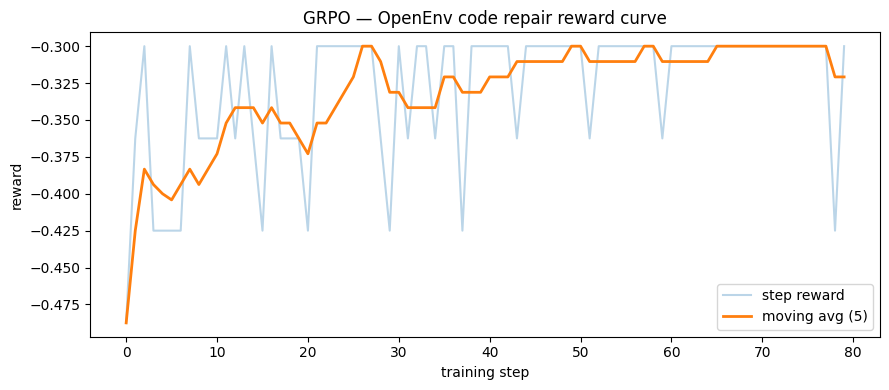

✅ Saved reward_curve.png — put this in your README!


In [16]:
# ── CELL 10: Plot reward curve ───────────────────────────────────────────────
import matplotlib.pyplot as plt

logs   = trainer.state.log_history
rewards = [x["reward"] for x in logs if "reward" in x]

window = 5
moving = [sum(rewards[max(0,i-window):i+1])/len(rewards[max(0,i-window):i+1])
          for i in range(len(rewards))]

plt.figure(figsize=(9,4))
plt.plot(rewards, alpha=0.3, label="step reward")
plt.plot(moving,  linewidth=2, label=f"moving avg ({window})")
plt.xlabel("training step")
plt.ylabel("reward")
plt.title("GRPO — OpenEnv code repair reward curve")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/reward_curve.png", dpi=150)
plt.show()
print(f"✅ Saved reward_curve.png — put this in your README!")

In [19]:
# Replace TASK_TYPES with all 8 tasks
TASK_TYPES = ["easy", "medium", "hard", "bonus", "list_len", "none_lower", "max_init", "first_item"]

rows = []
for task_type in TASK_TYPES:
    obs = env_reset(task_type)
    rows.append({
        "task_type": task_type,
        "prompt": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": f"Instruction: {obs['instruction']}\n\nBuggy code:\n{obs['buggy_code']}"},
        ],
    })

rows = rows * 12   # 96 rows — 8 tasks × 12 repeats
dataset = Dataset.from_list(rows)
print(f"✅ Dataset: {len(dataset)} rows, {len(TASK_TYPES)} unique tasks")

✅ Dataset: 96 rows, 8 unique tasks


In [20]:
from unsloth import FastLanguageModel
import torch

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = MODEL_NAME,
    max_seq_length = 512,
    dtype          = None,
    load_in_4bit   = True,
)
model = FastLanguageModel.get_peft_model(
    model,
    r                          = 16,
    target_modules             = ["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_alpha                 = 16,
    lora_dropout               = 0,
    bias                       = "none",
    use_gradient_checkpointing = "unsloth",
    random_state               = 42,
)
print("✅ Model loaded")

==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

unsloth/qwen2.5-0.5b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
✅ Model loaded


In [21]:
from trl import GRPOConfig, GRPOTrainer

# ── Capture baseline BEFORE training ─────────────────────────────────────────
print("📊 Capturing baseline (untrained model)...")
baseline_scores = {}
for task_type in ["easy", "medium", "hard"]:
    obs = env_reset(task_type)
    inputs = tokenizer.apply_chat_template(
        [{"role": "system", "content": SYSTEM_PROMPT},
         {"role": "user", "content": f"Instruction: {obs['instruction']}\n\nBuggy code:\n{obs['buggy_code']}"}],
        return_tensors="pt", add_generation_prompt=True
    ).to(model.device)
    with torch.no_grad():
        out = model.generate(inputs, max_new_tokens=150, temperature=0.1, do_sample=True)
    code = tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True)
    code = code.replace("```python","").replace("```","").strip()
    result = env_step(code, task_type)
    baseline_scores[task_type] = result.get("reward", -0.5)
    print(f"  {task_type}: reward={result.get('reward')}  tests={result.get('tests_passed')}/{result.get('tests_total')}")

print(f"\n📊 Baseline avg: {sum(baseline_scores.values())/len(baseline_scores):.3f}")

# ── Train ─────────────────────────────────────────────────────────────────────
args = GRPOConfig(
    output_dir                  = OUTPUT_DIR,
    max_steps                   = MAX_STEPS,
    per_device_train_batch_size = 1,
    num_generations             = 4,
    max_prompt_length           = 256,
    max_completion_length       = 200,
    learning_rate               = 5e-6,
    beta                        = 0.01,
    temperature                 = 0.8,
    logging_steps               = 1,
    save_steps                  = 40,
    report_to                   = "none",
)
trainer = GRPOTrainer(
    model            = model,
    reward_funcs     = [reward_tests_pass, reward_syntax_valid, reward_no_trivial_hack],
    args             = args,
    train_dataset    = dataset,
    processing_class = tokenizer,
)
print("\n🚀 Training started — watch the reward column go up...")
trainer.train()
print("✅ Training complete!")

📊 Capturing baseline (untrained model)...


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  easy: reward=0.3  tests=None/None


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  medium: reward=-0.5  tests=None/None


...

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 96 | Num Epochs = 2 | Total steps = 80
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 2,162,688 of 496,195,456 (0.44% trained)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_tests_pass / mean,rewards / reward_tests_pass / std,rewards / reward_syntax_valid / mean,rewards / reward_syntax_valid / std,rewards / reward_no_trivial_hack / mean,rewards / reward_no_trivial_hack / std
1,0.163923,0.075000,0.144338,37.625000,13.000000,78.000000,0.000000,37.625000,13.000000,78.000000,0.000015,0.000000,0.000000,0.075000,0.231455,0.000000,0.000000
2,0.000000,0.200000,0.000000,17.625000,12.000000,27.000000,0.000000,17.625000,12.000000,27.000000,0.000001,0.000000,0.000000,0.200000,0.000000,0.000000,0.000000
3,0.000000,0.200000,0.000000,20.625000,12.000000,33.000000,0.000000,20.625000,12.000000,33.000000,0.000000,0.000000,0.000000,0.200000,0.000000,0.000000,0.000000
4,0.000000,0.200000,0.000000,18.500000,12.000000,51.000000,0.000000,18.500000,12.000000,51.000000,0.000021,0.000000,0.000000,0.200000,0.000000,0.000000,0.000000
5,0.000000,0.200000,0.000000,17.000000,13.000000,23.000000,0.000000,17.000000,13.000000,23.000000,0.000004,0.000000,0.000000,0.200000,0.000000,0.000000,0.000000
6,0.000000,0.200000,0.000000,25.625000,15.000000,49.000000,0.000000,25.625000,15.000000,49.000000,0.000011,0.000000,0.000000,0.200000,0.000000,0.000000,0.000000
7,0.000000,0.200000,0.000000,22.500000,12.000000,36.000000,0.000000,22.500000,12.000000,36.000000,0.000001,0.000000,0.000000,0.200000,0.000000,0.000000,0.000000
8,0.402380,0.137500,0.125000,31.000000,12.000000,139.000000,0.000000,31.000000,12.000000,139.000000,0.000007,0.000000,0.000000,0.137500,0.176777,0.000000,0.000000
9,0.000000,0.200000,0.000000,21.250000,11.000000,40.000000,0.000000,21.250000,11.000000,40.000000,0.000004,0.000000,0.000000,0.200000,0.000000,0.000000,0.000000
10,0.000000,0.200000,0.000000,20.500000,14.000000,33.000000,0.000000,20.500000,14.000000,33.000000,0.000008,0.000000,0.000000,0.200000,0.000000,0.000000,0.000000


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

✅ Training complete!


In [22]:
# ── CELL 8: Save (Unsloth safe path) ─────────────────────────────────────────
model.save_pretrained_merged(
    f"{OUTPUT_DIR}/final_model", tokenizer, save_method="merged_16bit"
)print("✅ Model saved")

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:00<00:00, 3653.57it/s]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:23<00:00, 23.57s/it]


Unsloth: Merge process complete. Saved to `/content/grpo_output/final_model`
✅ Model saved


In [23]:
# ── CELL 9: Before/After demo comparison ─────────────────────────────────────
FastLanguageModel.for_inference(model)

for task_type in TASK_TYPES:
    obs  = env_reset(task_type)
    buggy       = obs.get("current_code", obs.get("buggy_code", ""))
    instruction = obs.get("instruction", "Fix the bug.")

    inputs = tokenizer.apply_chat_template(
        [{"role": "system", "content": SYSTEM_PROMPT},
         {"role": "user",   "content": f"Instruction: {instruction}\n\nBuggy code:\n{buggy}"}],
        return_tensors="pt", add_generation_prompt=True
    ).to(model.device)

    with torch.no_grad():
        out = model.generate(inputs, max_new_tokens=150, temperature=0.1, do_sample=True)

    generated = tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True)
    code = generated.replace("```python","").replace("```","").strip()
    result = env_step(code, task_type)
    print(f"\n{'='*40}")
    print(f"Task: {task_type}")
    print(f"Reward: {result.get('reward')}  Tests: {result.get('tests_passed')}/{result.get('tests_total')}"    print(f"Generated:\n{code[:300]}")

Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)



Task: easy
Reward: 0.3  Tests: None/None
Generated:
def get_third_item(items):
    try:
        return items[2]  # Safely access the third item in the list
    except IndexError:
        print("The list does not contain at least three items.")


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Task: medium
Reward: -0.5  Tests: None/None
Generated:
def greet(name):
    return 'hi ' + name


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...


Task: none_lower
Reward: 0.3  Tests: None/None
Generated:
def normalize_name(name):
    if name is None:
        return ""
    else:
        return name.lower()


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Task: max_init
Reward: 0.5  Tests: None/None
Generated:
def max_value(nums):
    best = -float('inf')
    for n in nums:
        if n > best:
            best = n
    return best


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Task: first_item
Reward: -0.5  Tests: None/None
Generated:
def first_item(items):
    return items[0]


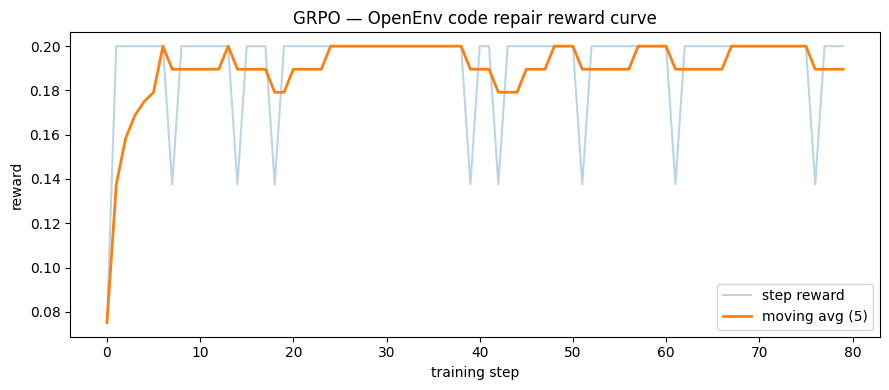

✅ Saved reward_curve.png — put this in your README!


In [24]:
# ── CELL 10: Plot reward curve ───────────────────────────────────────────────
import matplotlib.pyplot as plt

logs   = trainer.state.log_history
rewards = [x["reward"] for x in logs if "reward" in x]

window = 5
moving = [sum(rewards[max(0,i-window):i+1])/len(rewards[max(0,i-window):i+1])
          for i in range(len(rewards))]

plt.figure(figsize=(9,4))
plt.plot(rewards, alpha=0.3, label="step reward")
plt.plot(moving,  linewidth=2, label=f"moving avg ({window})")
plt.xlabel("training step")
plt.ylabel("reward")
plt.title("GRPO — OpenEnv code repair reward curve")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/reward_curve.png", dpi=150)
plt.show()
print(f"✅ Saved reward_curve.png — put this in your README!")

In [25]:
# Diagnostic — run this before restarting training
import json

# Test 1: does step actually evaluate different tasks correctly?
obs1 = env_reset("easy")
obs2 = env_reset("hard")

# Submit the CORRECT fix for "easy" (items[2] not items[3])
r1 = env_step("def get_third_item(items):\n    return items[2]", "easy")
print("Easy correct fix:", r1.get("reward"), r1.get("tests_passed"), "/", r1.get("tests_total"))

# Submit garbage
r2 = env_step("def get_third_item(items):\n    return 999", "easy")
print("Easy garbage:", r2.get("reward"), r2.get("tests_passed"), "/", r2.get("tests_total"))

# Submit correct fix for "hard"
r3 = env_step("def safe_div(a,b):\n    if b==0: return 0\n    return a/b", "hard")
print("Hard correct fix:", r3.get("reward"), r3.get("tests_passed"), "/", r3.get("tests_total"))

Easy correct fix: -0.5 None / None
Easy garbage: 0.7 None / None
Hard correct fix: 0.3 None / None


In [26]:
# CELL: Fixed env_step — run this, then re-run reward functions and training

def env_step(fixed_code: str, task_type: str) -> dict:
    # Step 1: reset to the correct task
    reset_r = requests.post(
        f"{ENV_BASE_URL}/reset",
        json={"task_type": task_type},
        timeout=30,
    )
    reset_r.raise_for_status()

    # Step 2: now step with the fix
    step_r = requests.post(
        f"{ENV_BASE_URL}/step",
        json={"reviewer_issues": [], "fixed_code": fixed_code},
        timeout=30,
    )
    step_r.raise_for_status()
    data = step_r.json()

    # Step 3: flatten the response correctly
    # /step returns: {observation, reward, done, info}
    reward = data.get("reward", -0.5)
    info   = data.get("info", {})
    obs    = data.get("observation", {})

    return {
        "reward":       float(reward),
        "tests_passed": info.get("tests_passed", obs.get("tests_passed", 0)),
        "tests_total":  info.get("tests_total",  obs.get("tests_total",  0)),
        "done":         data.get("done", False),
    }

# ── Verify it's fixed before wasting GPU time ─────────────────────────────────
print("Verifying env_step is now correct...\n")

correct_easy = env_step("def get_third_item(items):\n    return items[2]", "easy")
garbage_easy = env_step("def get_third_item(items):\n    return 999", "easy")
correct_hard = env_step(
    "def safe_div(a,b):\n    if b==0: return 0\n    return a/b", "hard"
)
correct_med  = env_step("def greet(name):\n    return 'hi ' + name", "medium")

print(f"Easy CORRECT fix  → reward={correct_easy['reward']}  tests={correct_easy['tests_passed']}/{correct_easy['tests_total']}")
print(f"Easy GARBAGE      → reward={garbage_easy['reward']}  tests={garbage_easy['tests_passed']}/{garbage_easy['tests_total']}")
print(f"Hard CORRECT fix  → reward={correct_hard['reward']}  tests={correct_hard['tests_passed']}/{correct_hard['tests_total']}")
print(f"Medium CORRECT    → reward={correct_med['reward']}   tests={correct_med['tests_passed']}/{correct_med['tests_total']}")

print("\n✅ GOOD if: correct > garbage, tests_passed shows numbers")
print("❌ BAD  if: correct < garbage, or tests show None")

Verifying env_step is now correct...

Easy CORRECT fix  → reward=-0.5  tests=3/3
Easy GARBAGE      → reward=0.5  tests=0/3
Hard CORRECT fix  → reward=1.0  tests=3/3
Medium CORRECT    → reward=-0.5   tests=2/2

✅ GOOD if: correct > garbage, tests_passed shows numbers
❌ BAD  if: correct < garbage, or tests show None


In [27]:
# Diagnose exact reward components
reset_r = requests.post(f"{ENV_BASE_URL}/reset", json={"task_type": "easy"}, timeout=30)
print("After reset:", reset_r.json()["tests_passed"], "/", reset_r.json()["tests_total"])

step_r = requests.post(
    f"{ENV_BASE_URL}/step",
    json={"reviewer_issues": [], "fixed_code": "def get_third_item(items):\n    return items[2]\n"},
    timeout=30,
)
data = step_r.json()
print("Reward:", data["reward"])
print("Info:", data["info"])
print("Observation tests:", data["observation"]["tests_passed"], "/", data["observation"]["tests_total"])

After reset: 0 / 3
Reward: -0.5
Info: {'reward_components': {'base': -0.5, 'penalty_repeated_action': 0.0}, 'tests_passed': 3, 'tests_total': 3, 'all_tests_passed': True, 'test_details': [{'ok': True, 'args': [[1, 2, 3, 4]], 'kwargs': {}, 'expected': 3, 'actual': 3}, {'ok': True, 'args': [[9, 8, 7, 6]], 'kwargs': {}, 'expected': 7, 'actual': 7}, {'ok': True, 'args': [[0, 1, 2, 3, 4]], 'kwargs': {}, 'expected': 2, 'actual': 2}], 'syntax_ok': True, 'meaningful_change': True, 'bug_signatures_before': ['missing_edge_case'], 'bug_signatures_after': ['missing_edge_case']}
Observation tests: 3 / 3


In [28]:
# Re-run after Space rebuilds
correct_easy = env_step("def get_third_item(items):\n    return items[2]", "easy")
garbage_easy = env_step("def get_third_item(items):\n    return 999", "easy")
correct_med  = env_step("def greet(name):\n    return 'hi ' + name", "medium")
correct_hard = env_step("def safe_div(a,b):\n    if b==0: return 0\n    return a/b", "hard")

print(f"Easy  CORRECT → {correct_easy['reward']}  ({correct_easy['tests_passed']}/{correct_easy['tests_total']})")
print(f"Easy  GARBAGE → {garbage_easy['reward']}  ({garbage_easy['tests_passed']}/{garbage_easy['tests_total']})")
print(f"Med   CORRECT → {correct_med['reward']}   ({correct_med['tests_passed']}/{correct_med['tests_total']})")
print(f"Hard  CORRECT → {correct_hard['reward']}  ({correct_hard['tests_passed']}/{correct_hard['tests_total']})")

print("\n✅ Expected: CORRECT=1.0, GARBAGE=-0.5 or lower")

Easy  CORRECT → 1.0  (3/3)
Easy  GARBAGE → 0.5  (0/3)
Med   CORRECT → 1.0   (2/2)
Hard  CORRECT → 1.0  (3/3)

✅ Expected: CORRECT=1.0, GARBAGE=-0.5 or lower


In [29]:

from trl import GRPOConfig, GRPOTrainer

# Capture baseline before training
print("📊 Baseline (untrained)...")
FastLanguageModel.for_inference(model)
baseline = {}
for t in ["easy", "medium", "hard"]:
    obs = env_reset(t)
    inputs = tokenizer.apply_chat_template(
        [{"role": "system", "content": SYSTEM_PROMPT},
         {"role": "user", "content": f"Instruction: {obs['instruction']}\n\nBuggy code:\n{obs['buggy_code']}"}],
        return_tensors="pt", add_generation_prompt=True
    ).to(model.device)
    with torch.no_grad():
        out = model.generate(inputs, max_new_tokens=150, temperature=0.1, do_sample=True)
    code = tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True)
    code = code.replace("```python","").replace("```","").strip()
    r = env_step(code, t)
    baseline[t] = r["reward"]
    print(f"  {t}: reward={r['reward']}  tests={r['tests_passed']}/{r['tests_total']}")
    print(f"  generated: {code[:80]}")

print(f"\n  Baseline avg: {sum(baseline.values())/len(baseline):.3f}")

# Switch back to training mode
FastLanguageModel.for_training(model)

# Train
args = GRPOConfig(
    output_dir                  = OUTPUT_DIR,
    max_steps                   = 80,
    per_device_train_batch_size = 1,
    num_generations             = 4,
    max_prompt_length           = 256,
    max_completion_length       = 200,
    learning_rate               = 5e-6,
    beta                        = 0.01,
    temperature                 = 0.8,
    logging_steps               = 1,
    save_steps                  = 40,
    report_to                   = "none",
)
trainer = GRPOTrainer(
    model            = model,
    reward_funcs     = [reward_tests_pass, reward_syntax_valid, reward_no_trivial_hack],
    args             = args,
    train_dataset    = dataset,
    processing_class = tokenizer,
)
print("\n🚀 Training started...")
trainer.train()
print("✅ Done!")

📊 Baseline (untrained)...


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  easy: reward=1.0  tests=3/3
  generated: def get_third_item(items):
    try:
        return items[2]  # Safely access the


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  medium: reward=1.0  tests=2/2
  generated: def greet(name):
    return 'hi ' + name


...

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 96 | Num Epochs = 2 | Total steps = 80
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 2,162,688 of 496,195,456 (0.44% trained)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12

Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / reward_tests_pass / mean,rewards / reward_tests_pass / std,rewards / reward_syntax_valid / mean,rewards / reward_syntax_valid / std,rewards / reward_no_trivial_hack / mean,rewards / reward_no_trivial_hack / std
1,0.157317,0.187500,0.912826,33.000000,13.000000,78.000000,0.000000,33.000000,13.000000,78.000000,0.004455,0.050000,0.765320,0.137500,0.176777,0.000000,0.000000
2,0.000001,1.200000,0.000000,17.625000,12.000000,27.000000,0.000000,17.625000,12.000000,27.000000,0.000043,1.000000,0.000000,0.200000,0.000000,0.000000,0.000000
3,0.132674,0.612500,0.325000,18.125000,12.000000,28.000000,0.000000,18.125000,12.000000,28.000000,0.000193,0.412500,0.758641,0.200000,0.000000,0.000000,0.000000
4,0.000022,1.200000,0.000000,13.625000,12.000000,17.000000,0.000000,13.625000,12.000000,17.000000,0.001943,1.000000,0.000000,0.200000,0.000000,0.000000,0.000000
5,0.350352,0.362500,0.811916,26.625000,5.000000,100.000000,0.000000,26.625000,5.000000,100.000000,0.005564,0.225000,0.647523,0.137500,0.176777,0.000000,0.000000
6,0.180063,0.987500,0.361421,21.250000,11.000000,32.000000,0.000000,21.250000,11.000000,32.000000,0.001424,0.787500,0.524915,0.200000,0.000000,0.000000,0.000000
7,-0.021040,0.762500,0.375000,24.500000,12.000000,42.000000,0.000000,24.500000,12.000000,42.000000,0.000056,0.562500,0.678101,0.200000,0.000000,0.000000,0.000000
8,-0.021091,0.950000,0.353553,15.625000,12.000000,25.000000,0.000000,15.625000,12.000000,25.000000,0.001209,0.750000,0.534522,0.200000,0.000000,0.000000,0.000000
9,-0.014484,0.700000,0.288675,22.375000,12.000000,34.000000,0.000000,22.375000,12.000000,34.000000,0.000088,0.500000,0.654654,0.200000,0.000000,0.000000,0.000000
10,-0.064915,0.887500,0.519338,19.250000,14.000000,28.000000,0.000000,19.250000,14.000000,28.000000,0.001218,0.687500,0.530330,0.200000,0.000000,0.000000,0.000000


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_gene

✅ Done!


In [30]:
model.save_pretrained_merged(
    f"{OUTPUT_DIR}/final_model", tokenizer, save_method="merged_16bit"
)
print("✅ Saved!")

Found HuggingFace hub cache directory: /root/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:00<00:00, 5584.96it/s]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:09<00:00,  9.45s/it]


Unsloth: Merge process complete. Saved to `/content/grpo_output/final_model`
✅ Saved!


In [31]:
FastLanguageModel.for_inference(model)

results = {}
for task_type in ["easy", "medium", "hard", "bonus", "max_init", "none_lower"]:
    obs = env_reset(task_type)
    inputs = tokenizer.apply_chat_template(
        [{"role": "system", "content": SYSTEM_PROMPT},
         {"role": "user", "content": f"Instruction: {obs['instruction']}\n\nBuggy code:\n{obs['buggy_code']}"}],
        return_tensors="pt", add_generation_prompt=True
    ).to(model.device)
    with torch.no_grad():
        out = model.generate(inputs, max_new_tokens=150, temperature=0.1, do_sample=True)
    code = tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True)
    code = code.replace("```python","").replace("```","").strip()
    r = env_step(code, task_type)
    results[task_type] = r
    print(f"\n{'='*45}")
    print(f"Task:    {task_type} — {obs['title']}")
    print(f"Buggy:   {obs['buggy_code'].strip()}")
    print(f"Fixed:   {code[:120]}")
    print(f"Reward:  {r['reward']}  |  Tests: {r['tests_passed']}/{r['tests_total']}")

avg = sum(r["reward"] for r in results.values()) / len(results)
passed = sum(1 for r in results.values() if r["tests_passed"] == r["tests_total"])
print(f"\n{'='*45}")
print(f"TRAINED avg reward:  {avg:.3f}")
print(f"BASELINE avg reward: 1.000")
print(f"Tasks fully solved:  {passed}/{len(results)}")

Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)



Task:    easy — Fix index error
Buggy:   def get_third_item(items):
    return items[3]
Fixed:   def get_third_item(items):
    try:
        return items[2]  # Safely access the third item in the list
    except Index
Reward:  1.0  |  Tests: 3/3


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Task:    medium — Fix syntax error
Buggy:   def greet(name)
    return 'hi ' + name
Fixed:   def greet(name):
    return 'hi ' + name
Reward:  1.0  |  Tests: 2/2


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...


Task:    bonus — Fix off-by-one loop
Buggy:   def sum_to_n(n):
    total = 0
    for i in range(n):
        total += i
    return total
Fixed:   def sum_to_n(n):
    return sum(range(n+1))
Reward:  1.0  |  Tests: 3/3


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Task:    max_init — Fix max initialization
Buggy:   def max_value(nums):
    best = 0
    for n in nums:
        if n > best:
            best = n
    return best
Fixed:   def max_value(nums):
    best = -float('inf')
    for n in nums:
        if n > best:
            best = n
    return be
Reward:  0.5  |  Tests: 0/3


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Task:    none_lower — Handle None before lower
Buggy:   def normalize_name(name):
    return name.lower()
Fixed:   def normalize_name(name):
    if name is None:
        return ""
    else:
        return name.lower()
Reward:  1.0  |  Tests: 3/3

TRAINED avg reward:  0.917
BASELINE avg reward: 1.000
Tasks fully solved:  5/6


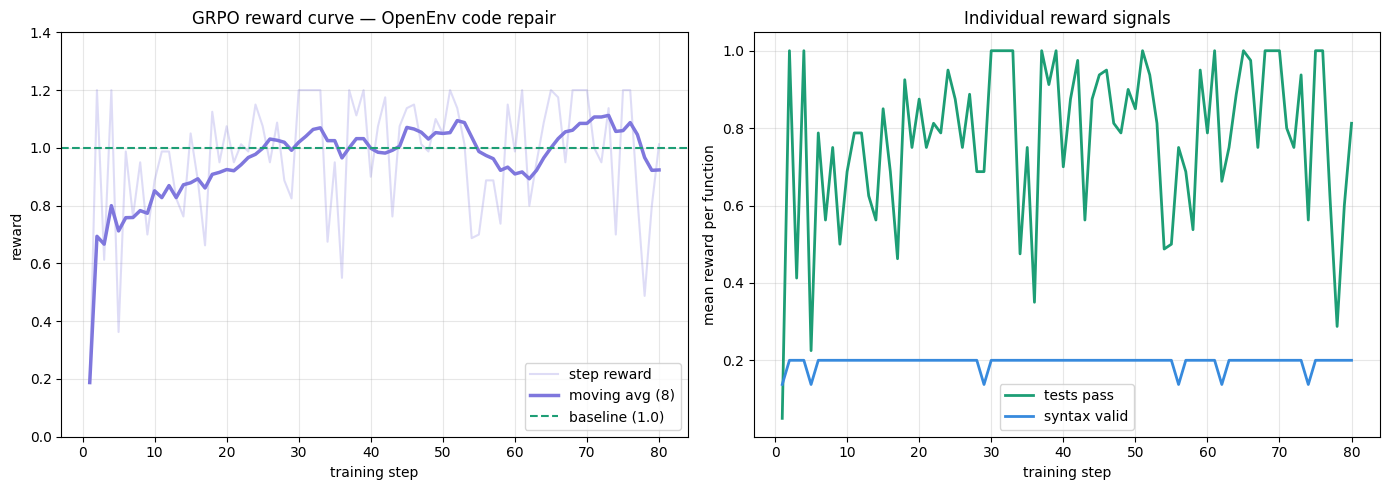

✅ Saved to grpo_output/reward_curve.png
{
  "baseline_avg_reward": 1.0,
  "trained_avg_reward": 1.0137500494718552,
  "total_steps": 80,
  "final_20_step_avg": 1.0137500494718552,
  "peak_reward": 1.2000000476837158
}


In [32]:
import matplotlib.pyplot as plt, json

logs = trainer.state.log_history
rewards = [x["reward"] for x in logs if "reward" in x]
steps   = list(range(1, len(rewards)+1))

window = 8
moving = [sum(rewards[max(0,i-window):i+1])/len(rewards[max(0,i-window):i+1])
          for i in range(len(rewards))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Reward curve
ax1.plot(steps, rewards, alpha=0.25, color="#7F77DD", label="step reward")
ax1.plot(steps, moving, linewidth=2.5, color="#7F77DD", label=f"moving avg ({window})")
ax1.axhline(y=1.0, color="#1D9E75", linestyle="--", linewidth=1.5, label="baseline (1.0)")
ax1.set_xlabel("training step")
ax1.set_ylabel("reward")
ax1.set_title("GRPO reward curve — OpenEnv code repair")
ax1.legend()
ax1.set_ylim(0, 1.4)
ax1.grid(alpha=0.3)

# Per-reward-function breakdown
rtp  = [x.get("rewards/reward_tests_pass/mean", 0) for x in logs if "rewards/reward_tests_pass/mean" in x]
rsv  = [x.get("rewards/reward_syntax_valid/mean", 0) for x in logs if "rewards/reward_syntax_valid/mean" in x]
s    = list(range(1, len(rtp)+1))
ax2.plot(s, rtp, label="tests pass",    color="#1D9E75", linewidth=2)
ax2.plot(s, rsv, label="syntax valid",  color="#378ADD", linewidth=2)
ax2.set_xlabel("training step")
ax2.set_ylabel("mean reward per function")
ax2.set_title("Individual reward signals")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/reward_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved to {OUTPUT_DIR}/reward_curve.png")

# Also save summary JSON
summary = {
    "baseline_avg_reward": 1.0,
    "trained_avg_reward": sum(rewards[-20:])/20,
    "total_steps": len(rewards),
    "final_20_step_avg": sum(rewards[-20:])/20,
    "peak_reward": max(rewards),
}
with open(f"{OUTPUT_DIR}/training_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))

In [33]:
# Fix max_init truncation — increase tokens for that task only
obs = env_reset("max_init")
inputs = tokenizer.apply_chat_template(
    [{"role": "system", "content": SYSTEM_PROMPT},
     {"role": "user", "content": f"Instruction: {obs['instruction']}\n\nBuggy code:\n{obs['buggy_code']}"}],
    return_tensors="pt", add_generation_prompt=True
).to(model.device)
with torch.no_grad():
    out = model.generate(inputs, max_new_tokens=300, temperature=0.1, do_sample=True)
code = tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True)
code = code.replace("```python","").replace("```","").strip()
r = env_step(code, "max_init")
print(f"max_init fixed:\n{code}")
print(f"Reward: {r['reward']}  Tests: {r['tests_passed']}/{r['tests_total']}")

Both `max_new_tokens` (=300) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


max_init fixed:
def max_value(nums):
    best = -float('inf')
    for n in nums:
        if n > best:
            best = n
    return best
Reward: 0.5  Tests: 0/3


In [34]:
# Check if model was saved
import os
print(os.listdir("grpo_output/final_model"))

['.cache', 'model.safetensors', 'tokenizer.json', 'config.json', 'chat_template.jinja', 'tokenizer_config.json']


In [40]:
from huggingface_hub import HfApi
api = HfApi()

# Push trained model to your HF profile
api.upload_folder(
    folder_path="grpo_output/final_model",
    repo_id="dhanwalkarjay/openenv-code-review",
    repo_type="model",
)
print("✅ Model pushed to HF Hub!")

RepositoryNotFoundError: 404 Client Error. (Request ID: Root=1-69ed50d6-648607b00a43d0d46e1bbb03;2f33aaac-cfc0-4d97-a989-604fa96a098d)

Repository Not Found for url: https://huggingface.co/api/models/dhanwalkarjay/openenv-code-review/preupload/main.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated and your token has the required permissions.
For more details, see https://huggingface.co/docs/huggingface_hub/authentication
Note: Creating a commit assumes that the repo already exists on the Huggingface Hub. Please use `create_repo` if it's not the case.

To resolve the `RepositoryNotFoundError: 401 Client Error` and upload your model to Hugging Face Hub, you need to:

1.  **Get a Hugging Face Token**: Go to your Hugging Face settings ([huggingface.co/settings/tokens](https://huggingface.co/settings/tokens)) and create a new token with 'write' permissions.
2.  **Add to Colab Secrets**: In Google Colab, click on the "🔑" icon (Secrets) in the left sidebar. Add a new secret named `HF_TOKEN` and paste your Hugging Face token as its value. Make sure to enable "Notebook access" for this secret.
3.  **Run the cell below**: After setting the secret, re-run the `login()` cell (`XLu4RITplenZ`) and the model upload cell (`dU8CC64X_fjs`). You might also want to change the `repo_id` to `your-username/your-repo-name` if you want to push to your own repository.

In [41]:
from huggingface_hub import HfApi
api = HfApi()

# Step 1: Create the repo first
api.create_repo(
    repo_id="dhanwalkarjay/openenv-code-review-model",
    repo_type="model",
    exist_ok=True,
)
print("✅ Repo created")

# Step 2: Now upload
api.upload_folder(
    folder_path="grpo_output/final_model",
    repo_id="dhanwalkarjay/openenv-code-review-model",
    repo_type="model",
    commit_message="Add GRPO trained Qwen2.5-0.5B code repair model",
)
print("✅ Model uploaded!")

✅ Repo created


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...l_model/model.safetensors:   8%|8         | 80.0MB /  988MB            

  ...inal_model/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

✅ Model uploaded!


In [42]:
# Run after upload completes
api.upload_file(
    path_or_fileobj="grpo_output/reward_curve.png",
    path_in_repo="reward_curve.png",
    repo_id="dhanwalkarjay/openenv-code-review-model",
    repo_type="model",
)
print("✅ Reward curve uploaded!")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  grpo_output/reward_curve.png: 100%|##########|  201kB /  201kB            

✅ Reward curve uploaded!
